## Import Test

In [23]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# Ensure project root is on sys.path regardless of notebook launch directory
import sys
project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.dataset_pipeline.dataset_loader import DatasetLoader
print("DatasetLoader imported successfully")

DatasetLoader imported successfully


In [28]:
image_dir = Path("~/HS202_repo/dataset/WorldExpo'10/part_B_final/test_data/images").expanduser()
gt_dir = Path("~/HS202_repo/dataset/WorldExpo'10/part_B_final/test_data/ground_truth/").expanduser()
loader = DatasetLoader(image_dir, gt_dir)
print(f"Number of samples in the dataset: {len(loader)}")

Number of samples in the dataset: 316


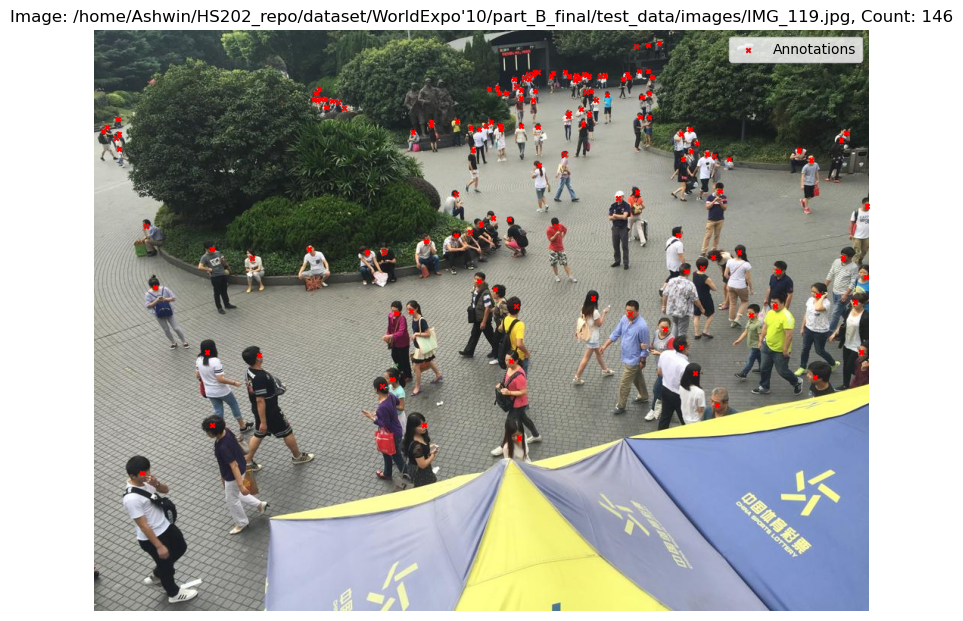

In [ ]:
import matplotlib.pyplot as plt

# Get a sample (e.g., the first one)
sample = loader[]
image = sample["image"]
points = sample["points"]

plt.figure(figsize=(10, 8))
plt.imshow(image[..., ::-1])  # Convert BGR (OpenCV) to RGB for matplotlib

if points is not None and len(points) > 0:
    # If points are (N, 2) array: [x, y]
    plt.scatter(points[:, 0], points[:, 1], c='red', s=10, label='Annotations', marker='x')

plt.title(f"Image: {sample['path']}, Count: {sample['count']}")
plt.axis('off')
plt.legend()
plt.show()

In [6]:
print(points.shape)
print(points[:5])  # Show first 5 points

(234, 2)
[[ 32.67954877 753.52165403]
 [184.60695349 690.79933098]
 [344.89733461 577.8991495 ]
 [328.1713818  536.08426746]
 [329.5652112  473.36194441]]


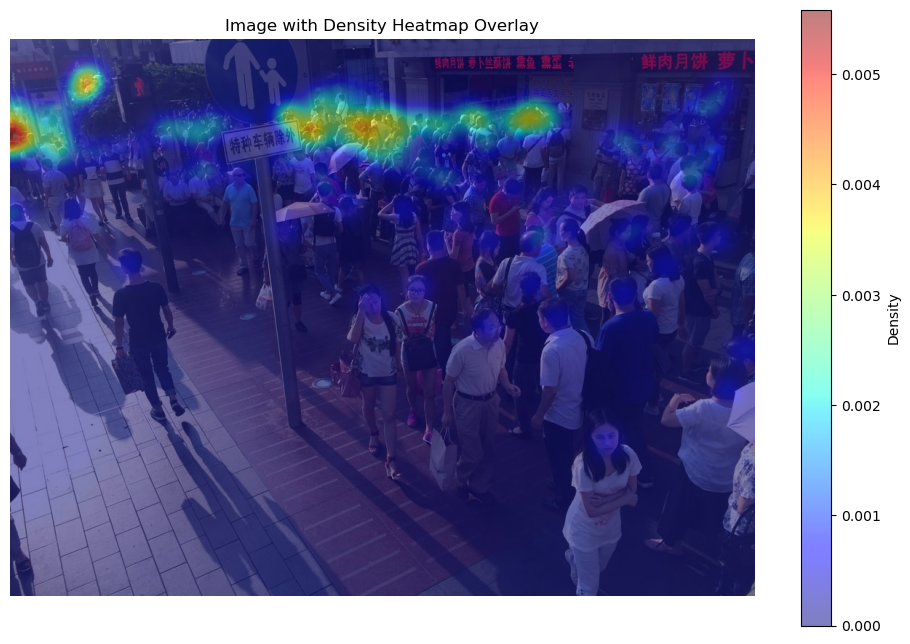

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# Get image and points
sample = loader[2]
image = sample["image"]
points = sample["points"]

# Create an empty density map
density = np.zeros((image.shape[0], image.shape[1]), dtype=np.float32)

# Place a 1 at each annotation point (rounded to nearest integer pixel)
for x, y in points:
    x = int(round(x))
    y = int(round(y))
    if 0 <= y < density.shape[0] and 0 <= x < density.shape[1]:
        density[y, x] += 1

# Apply Gaussian filter to spread the points (adjust sigma as needed)
density = gaussian_filter(density, sigma=15)

# Plot the image and overlay the heatmap
plt.figure(figsize=(12, 8))
plt.imshow(image[..., ::-1])  # BGR to RGB
plt.imshow(density, cmap='jet', alpha=0.5)  # Heatmap overlay
plt.title("Image with Density Heatmap Overlay")
plt.axis('off')
plt.colorbar(label='Density')
plt.show()

In [38]:
import os
import cv2
import numpy as np
from scipy.io import loadmat

# load ground truth
gt_path = os.path.expanduser('~/HS202_repo/dataset/Mall_dataset/mall_gt.mat')
gt = loadmat(gt_path)

# load perspective + ROI
persp_data = loadmat(os.path.expanduser('~/HS202_repo/dataset/Mall_dataset/perspective_roi.mat'))
pMap = persp_data['pMapN']      # perspective
roi = persp_data['roi']        # region of interest

In [40]:
print(gt.keys())
frame_data = gt['frame']
print(frame_data.shape)
frame_1_points = frame_data.size  # nested structured array: [row, col][0][0] gives the points array
print(frame_1_points)  # print first 5 points for frame 1

dict_keys(['__header__', '__version__', '__globals__', 'frame', 'count'])
(1, 2000)
2000
